# Asociación del inventario a las slope units — Capítulo 5

**Tesis MSc — Oscar I. Sánchez P.**

Este cuaderno asocia cada evento del inventario (con fecha, hora y coordenadas) a la slope unit que lo contiene, y produce la capa de entrada para los modelos de umbrales de lluvia del Capítulo 5.

## Qué cambia respecto al cuaderno del Capítulo 6

| | Capítulo 6 | **Capítulo 5 (este cuaderno)** |
|---|---|---|
| Dominio espacial | solo SU susceptibles (`incluir_parte2 == True`) | **todas** las SU del Valle de Aburrá |
| Filtro previo | susceptibilidad ZINB+BYM2 | solo el de pendiente media $\leq 10^\circ$, ya aplicado en el Cap. 4 |
| Motivo | la Parte 2 parte del modelo de susceptibilidad | en el Cap. 5 aún no existe ese modelo: los umbrales se entrenan sobre todo el valle |

Es decir: **se elimina el filtro `incluir_parte2`**. El único terreno excluido es el que ya excluyó el Capítulo 4 (pendiente media $\leq 10^\circ$: llanura aluvial del río Aburrá y los altiplanos de Santa Elena y San Pedro).

## Pasos

1. Cargar las slope units y el inventario.
2. Validar coordenadas y construir la capa de puntos.
3. Diagnosticar qué eventos caen dentro y cuáles fuera del mosaico de SU, con la distancia a la SU más cercana.
4. Spatial join `contains`: una fila por evento (las SU con varios eventos se duplican).
5. Crear `mm_si` (1 = fila con evento, 0 = sin evento).
6. Reportar presencias a nivel **slope unit-día**, que es la unidad real del modelo.
7. Mapa de validación y resumen para la tesis.
8. Guardar el GeoPackage.

## 1. Librerías y configuración

In [15]:
import os
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore', category=UserWarning)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.dpi': 110,
})

# ------------------------------------------------------------------ rutas
PATH_SU   = 'slope_units_final_mm.gpkg'
LAYER_IN  = 'slope_units_final_mm'          # None -> primera capa del gpkg
PATH_INV  = '/home/oisanchezp/Thesis/data/processed/inventario_unificado.csv'

PATH_OUT  = 'su_todas_con_inventario.gpkg'
LAYER_OUT = 'slope_units_cap5'

# ------------------------------------------------------------- parámetros
# Distancia máxima para reasignar un evento que cayó en un hueco del mosaico
# a la SU más cercana. 0 = desactivado (solo se reporta el diagnóstico).
# Súbelo (p. ej. 50) solo si el diagnóstico del paso 3 muestra que esos
# eventos están a pocos metros del borde de una SU, es decir, que se trata
# de imprecisión posicional y no de terreno realmente excluido.
SNAP_TOL_M = 50

# Variables que el Capítulo 5 necesita en la capa de salida
COLS_MODELO = ['slope_mean', 'curva_mean', 'cobertura', 'suelos']

## 2. Carga de datos

`slope_units_final_mm.gpkg` es la partición del Capítulo 4, que ya tiene aplicado el filtro de pendiente media $\leq 10^\circ$. **No se aplica ningún filtro adicional.**

In [16]:
su = (gpd.read_file(PATH_SU, layer=LAYER_IN) if LAYER_IN
      else gpd.read_file(PATH_SU))
inv = pd.read_csv(PATH_INV)

print(f'Slope Units          : {len(su):,}   | CRS: {su.crs}')
print(f'Eventos del inventario: {len(inv):,}')
print(f'Columnas de la capa   : {len(su.columns)}')

# --- comprobar que están las variables del modelo del Cap. 5
faltan = [c for c in COLS_MODELO if c not in su.columns]
if faltan:
    print(f'\nATENCION - faltan columnas del modelo: {faltan}')
    print(f'Disponibles: {sorted(su.columns.tolist())}')
else:
    print('\nVariables del modelo presentes. Nulos por columna:')
    print(su[COLS_MODELO].isna().sum().to_string())

# --- confirmar el filtro de 10 grados heredado del Capitulo 4
if 'slope_mean' in su.columns:
    n_bajo = int((su['slope_mean'] <= 10).sum())
    print(f'\nSU con pendiente media <= 10 grados: {n_bajo} '
          f'(deberia ser 0; el filtro viene del Cap. 4)')
    print(f'Pendiente media: min={su["slope_mean"].min():.1f} | '
          f'max={su["slope_mean"].max():.1f}')

Slope Units          : 61,073   | CRS: EPSG:3116
Eventos del inventario: 496
Columnas de la capa   : 29

Variables del modelo presentes. Nulos por columna:
slope_mean     0
curva_mean     0
cobertura     95
suelos         0

SU con pendiente media <= 10 grados: 0 (deberia ser 0; el filtro viene del Cap. 4)
Pendiente media: min=10.0 | max=63.2


## 3. Inventario: inspección y validación de coordenadas

Se rechazan las coordenadas fuera del rango continental de Colombia (lat $\in [-5, 13]$, lon $\in [-82, -66]$). En el inventario suele haber errores de signo o de escala que producen puntos imposibles.

In [17]:
print('Columnas del inventario:', list(inv.columns))
display(inv.head(3))

lat_ok = inv['latitud'].between(-5, 13)
lon_ok = inv['longitud'].between(-82, -66)
coords_ok = lat_ok & lon_ok

print(f'\nEventos con coordenadas validas  : {int(coords_ok.sum())}')
print(f'Eventos con coordenadas invalidas: {int((~coords_ok).sum())}')
if (~coords_ok).any():
    print('\nRevisar en el CSV de origen:')
    print(inv.loc[~coords_ok, ['fecha_hora_evento', 'latitud', 'longitud',
                               'municipio', 'vereda_barrio']].to_string())

inv_valid = inv[coords_ok].copy()

events = gpd.GeoDataFrame(
    inv_valid,
    geometry=gpd.points_from_xy(inv_valid['longitud'], inv_valid['latitud']),
    crs='EPSG:4326',
).to_crs(su.crs).reset_index(drop=True)

# Renombrar para evitar colisiones con columnas de la capa de SU
events = events.rename(columns={
    'tipo_movimiento_masa': 'tipo_movimiento',
    'Codigo':               'Codigo_estacion',
    'si_no':                'si_no_evento',
})

COLS_EVENTO = ['fecha_hora_evento', 'latitud', 'longitud', 'tipo_movimiento',
               'municipio', 'corregimiento', 'vereda_barrio',
               'Codigo_estacion', 'incertidumbre_fecha',
               'incertidumbre_ubicacion']
COLS_EVENTO = [c for c in COLS_EVENTO if c in events.columns]

conflictos = sorted(set(su.columns) & set(events.columns) - {'geometry'})
print(f'\nColumnas del evento a propagar: {COLS_EVENTO}')
print(f'Conflictos de nombre SU vs evento: {conflictos}')

Columnas del inventario: ['fecha_hora_evento', 'incertidumbre_fecha', 'latitud', 'longitud', 'incertidumbre_ubicacion', 'tipo_movimiento_masa', 'municipio', 'corregimiento', 'vereda_barrio', 'Codigo', 'si_no']


,fecha_hora_evento,incertidumbre_fecha,latitud,longitud,incertidumbre_ubicacion,tipo_movimiento_masa,municipio,corregimiento,vereda_barrio,Codigo,si_no
0,2014-10-30 04:00:00,baja,6.316441,-75.579412,baja,Deslizamiento,Bello,NaN,Nueva Jerusalen,89,NaN
1,2016-10-10 21:00:00,baja,6.442787,-75.362489,baja,Flujo,Barbosa,El Hatillo,Quebrada El Bebedero El Chocho,30,NaN
2,2016-10-26 07:00:00,baja,6.319923,-75.486939,baja,Flujo,Copacabana,NaN,El Cabuyal,70,NaN



Eventos con coordenadas validas  : 496
Eventos con coordenadas invalidas: 0

Columnas del evento a propagar: ['fecha_hora_evento', 'latitud', 'longitud', 'tipo_movimiento', 'municipio', 'corregimiento', 'vereda_barrio', 'Codigo_estacion', 'incertidumbre_fecha', 'incertidumbre_ubicacion']
Conflictos de nombre SU vs evento: []


## 4. Diagnóstico: eventos dentro y fuera del mosaico de slope units

Como aquí NO hay filtro de susceptibilidad, un evento solo puede quedar fuera por una razón: cayó en un **hueco del mosaico**, es decir, en terreno que el Capítulo 4 excluyó por tener pendiente media $\leq 10^\circ$ (llanura aluvial, altiplanos) o en un vacío de la partición.

Para cada evento fuera se calcula la **distancia a la slope unit más cercana**. Ese número decide qué hacer:

- distancia pequeña (decenas de metros) → probable imprecisión posicional del registro; se puede reasignar con `SNAP_TOL_M`;
- distancia grande → el evento ocurrió de verdad en terreno excluido, y eso hay que **reportarlo como limitación**, no esconderlo.

In [18]:
# ¿Cada evento cae dentro de alguna SU?
chk = gpd.sjoin(events[['geometry']], su[['geometry']],
                how='left', predicate='within')
dentro = chk.groupby(chk.index)['index_right'].apply(lambda s: s.notna().any())
dentro = dentro.reindex(events.index, fill_value=False)

events_in  = events.loc[dentro].copy()
events_out = events.loc[~dentro].copy()

print(f'Eventos con coordenadas validas : {len(events)}')
print(f'  dentro de alguna slope unit   : {len(events_in)}')
print(f'  fuera (huecos del mosaico)    : {len(events_out)}')

# Distancia a la SU mas cercana para los que quedaron fuera
if len(events_out):
    try:
        near = gpd.sjoin_nearest(events_out[['geometry']], su[['geometry']],
                                 how='left', distance_col='dist_su_m')
        near = near[~near.index.duplicated(keep='first')]
        events_out['dist_su_m'] = near['dist_su_m'].to_numpy()
    except Exception:
        # geopandas antiguo: calculo directo (mas lento)
        events_out['dist_su_m'] = [float(su.distance(g).min())
                                   for g in events_out.geometry]

    cols = [c for c in ['fecha_hora_evento', 'municipio', 'vereda_barrio',
                        'dist_su_m'] if c in events_out.columns]
    print('\nEventos fuera del mosaico, ordenados por distancia a la SU mas cercana:')
    print(events_out[cols].sort_values('dist_su_m').to_string())
    print(f'\nDistancia: mediana={events_out["dist_su_m"].median():.0f} m | '
          f'max={events_out["dist_su_m"].max():.0f} m')
    print(f'A menos de 50 m de una SU: '
          f'{int((events_out["dist_su_m"] <= 50).sum())} de {len(events_out)}')

Eventos con coordenadas validas : 496
  dentro de alguna slope unit   : 481
  fuera (huecos del mosaico)    : 15

Eventos fuera del mosaico, ordenados por distancia a la SU mas cercana:
       fecha_hora_evento municipio         vereda_barrio   dist_su_m
359  2022-10-24 17:30:00  Medellín       Los Balsos No.1    0.419368
182  2021-11-25 15:30:00  Medellín             Altavista    0.841825
263  2022-05-10 17:00:00  Medellín                  Mazo    9.907051
157  2021-06-11 17:30:00  Medellín  Los Cerros El Vergel   15.578515
483  2024-06-26 14:00:00  Medellín              La Palma   16.883571
445  2023-11-24 23:59:00  Medellín               Betania   17.219244
458  2024-05-15 23:00:00  Medellín          Barro Blanco   20.106030
194  2021-11-30 23:00:00  Medellín            La piñuela   23.713239
203  2021-11-30 23:00:00  Medellín            La piñuela   25.218081
433  2023-10-31 18:00:00  Medellín              Aranjuez   35.606436
186  2021-11-30 22:00:00  Medellín           El Diamant

## 5. Reasignación opcional de los eventos en huecos

Solo se ejecuta si `SNAP_TOL_M > 0`. Reasigna a la slope unit más cercana los eventos que estén dentro de esa tolerancia, moviendo el punto al centroide de esa unidad para que el `sjoin` posterior los recoja.

**Documenta la decisión en la tesis**: cuántos eventos se reasignaron y con qué tolerancia. Si dejas `SNAP_TOL_M = 0`, di cuántos eventos se perdieron y por qué.

In [19]:
n_snap = 0
if SNAP_TOL_M > 0 and len(events_out):
    cerca = events_out[events_out['dist_su_m'] <= SNAP_TOL_M].copy()
    if len(cerca):
        near = gpd.sjoin_nearest(cerca[['geometry']], su[['geometry']],
                                 how='left', distance_col='d')
        near = near[~near.index.duplicated(keep='first')]
        cerca['geometry'] = su.loc[near['index_right'].to_numpy(),
                                   'geometry'].centroid.to_numpy()
        cerca = cerca.drop(columns=['dist_su_m'], errors='ignore')
        events_in = pd.concat([events_in, cerca], ignore_index=False)
        events_out = events_out[events_out['dist_su_m'] > SNAP_TOL_M]
        n_snap = len(cerca)

print(f'Eventos reasignados a la SU mas cercana (tol={SNAP_TOL_M} m): {n_snap}')
print(f'Eventos que entran al spatial join: {len(events_in)}')
print(f'Eventos definitivamente fuera     : {len(events_out)}')

Eventos reasignados a la SU mas cercana (tol=50 m): 11
Eventos que entran al spatial join: 492
Eventos definitivamente fuera     : 4


## 6. Spatial join: un evento, una fila

Cada slope unit recibe los eventos que contiene. Una unidad con $n$ eventos se duplica $n$ veces, con los mismos atributos estáticos y distinta `fecha_hora_evento`. La columna `mm_si` vale 1 en esas filas y 0 en el resto.

In [20]:
events_join = events_in[COLS_EVENTO + ['geometry']]

joined = gpd.sjoin(su, events_join, how='left', predicate='contains')
joined = joined.drop(columns=['index_right'])
joined['mm_si'] = joined['fecha_hora_evento'].notna().astype(int)
joined = joined.reset_index(drop=True)

print(f'Slope units de entrada : {len(su):,}')
print(f'Filas en la capa final : {len(joined):,}')
print(f'  con evento  (mm_si=1): {int((joined.mm_si == 1).sum()):,}')
print(f'  sin evento  (mm_si=0): {int((joined.mm_si == 0).sum()):,}')
print(f'\nFilas extra por SU con varios eventos: {len(joined) - len(su):,}')

# Control: los eventos asociados deben coincidir con los que entraron
n_asociados = int((joined.mm_si == 1).sum())
if n_asociados != len(events_in):
    print(f'\nATENCION: {n_asociados} filas con evento vs {len(events_in)} eventos '
          f'de entrada. Revisa solapamientos entre poligonos de SU.')

Slope units de entrada : 61,073
Filas en la capa final : 61,167
  con evento  (mm_si=1): 492
  sin evento  (mm_si=0): 60,675

Filas extra por SU con varios eventos: 94


## 7. Presencias a nivel slope unit–día

Este es el número que hay que citar en el capítulo. El modelo trabaja con la combinación **slope unit × día**, así que dos deslizamientos en la misma unidad y el mismo día son **una sola presencia**, no dos. La diferencia entre el número de registros y el de presencias explica la discrepancia entre las cifras del inventario y las del modelo.

In [21]:
id_col = 'su_id' if 'su_id' in joined.columns else 'Id'

ev = joined[joined.mm_si == 1].copy()
ev['fecha_dia'] = pd.to_datetime(ev['fecha_hora_evento']).dt.normalize()

n_registros = len(ev)
n_su_dia    = ev.drop_duplicates(subset=[id_col, 'fecha_dia']).shape[0]
n_su_unicas = ev[id_col].nunique()
n_dias      = ev['fecha_dia'].nunique()

print(f'Registros de deslizamiento asociados : {n_registros:,}')
print(f'Presencias unicas (slope unit-dia)   : {n_su_dia:,}   <-- usar esta en el modelo')
print(f'Slope units distintas con evento     : {n_su_unicas:,}')
print(f'Dias distintos con evento            : {n_dias:,}')

print('\nRegistros por slope unit:')
dist = ev.groupby(id_col).size().value_counts().sort_index()
dist.index.name = 'registros_por_SU'
dist.name = 'numero_de_SU'
print(dist.to_string())

print('\nRegistros por dia (dias multi-evento):')
por_dia = ev.groupby('fecha_dia').size().sort_values(ascending=False)
print(f'  dias con 1 registro : {int((por_dia == 1).sum())}')
print(f'  dias con 2-4        : {int(por_dia.between(2, 4).sum())}')
print(f'  dias con 5 o mas    : {int((por_dia >= 5).sum())}')
print('\n  Los 10 dias mas activos:')
print(por_dia.head(10).to_string())

Registros de deslizamiento asociados : 492
Presencias unicas (slope unit-dia)   : 450   <-- usar esta en el modelo
Slope units distintas con evento     : 398
Dias distintos con evento            : 157

Registros por slope unit:
registros_por_SU
1    324
2     57
3     15
4      1
5      1

Registros por dia (dias multi-evento):
  dias con 1 registro : 73
  dias con 2-4        : 57
  dias con 5 o mas    : 27

  Los 10 dias mas activos:
fecha_dia
2025-05-05    26
2021-11-30    23
2025-04-29    22
2022-10-24    16
2023-05-28    15
2022-04-05    13
2022-08-01    10
2024-06-28    10
2022-08-06     9
2022-03-29     9


## 8. Mapa de validación

- Gris: slope units sin evento.
- Rojo: slope units con al menos un evento.
- Negro: eventos asociados.
- Cian (×): eventos en huecos del mosaico (terreno excluido en el Cap. 4).

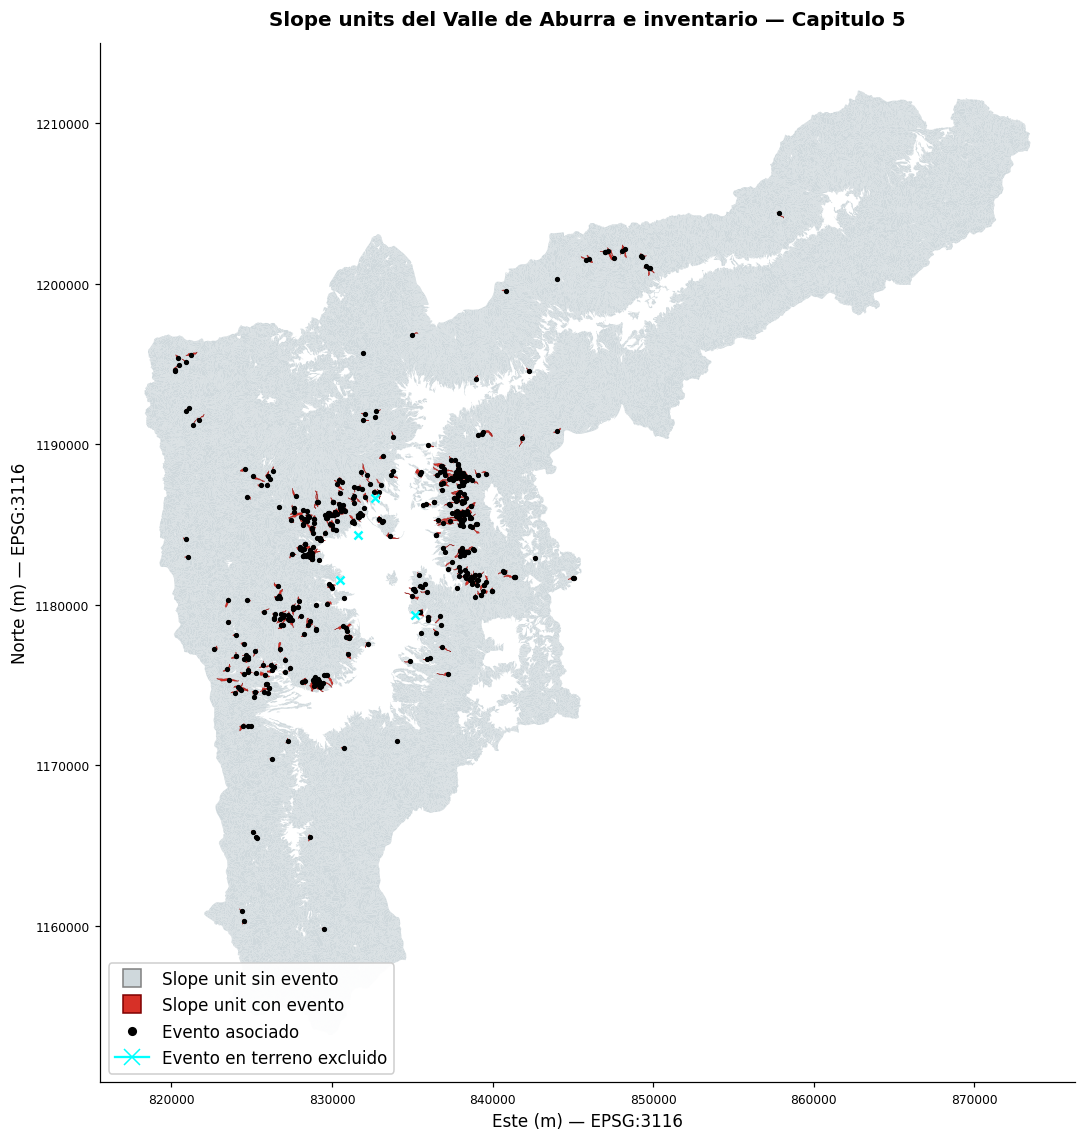

In [22]:
su_unicas = (joined[[id_col, 'mm_si', 'geometry']]
             .groupby(id_col, as_index=False)
             .agg({'mm_si': 'max', 'geometry': 'first'}))
su_unicas = gpd.GeoDataFrame(su_unicas, geometry='geometry', crs=su.crs)

fig, ax = plt.subplots(figsize=(10, 11))

su_unicas[su_unicas.mm_si == 0].plot(ax=ax, color='#cfd8dc',
                                     edgecolor='none', linewidth=0)
su_unicas[su_unicas.mm_si == 1].plot(ax=ax, color='#d73027',
                                     edgecolor='#7f0000', linewidth=0.2)
events_in.plot(ax=ax, color='black', markersize=6, marker='o')
if len(events_out):
    events_out.plot(ax=ax, color='cyan', markersize=28, marker='x',
                    linewidth=1.6)

handles = [
    Line2D([], [], marker='s', color='w', markerfacecolor='#cfd8dc',
           markeredgecolor='gray', markersize=12, label='Slope unit sin evento'),
    Line2D([], [], marker='s', color='w', markerfacecolor='#d73027',
           markeredgecolor='#7f0000', markersize=12, label='Slope unit con evento'),
    Line2D([], [], marker='o', color='w', markerfacecolor='black',
           markersize=7, label='Evento asociado'),
    Line2D([], [], marker='x', color='cyan', markersize=10,
           label='Evento en terreno excluido'),
]
ax.legend(handles=handles, loc='lower left', frameon=True, framealpha=0.95)
ax.set_aspect('equal')
ax.set_title('Slope units del Valle de Aburra e inventario — Capitulo 5', pad=12)
ax.set_xlabel(f'Este (m) — {su.crs}')
ax.set_ylabel(f'Norte (m) — {su.crs}')
ax.ticklabel_format(style='plain', useOffset=False)
ax.tick_params(labelsize=8)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
# plt.savefig('mapa_su_inventario_cap5.png', dpi=200, bbox_inches='tight')
plt.show()

## 9. Resumen para el capítulo

Los conteos que se citan en la Sección 5.2.2 (inventario) y en la 5.3.2 (muestreo).

In [23]:
n_pos = int((joined.mm_si == 1).sum())
n_neg = int((joined.mm_si == 0).sum())

print('=== BALANCE ===')
print(f'Filas mm_si = 1 : {n_pos:>8,}')
print(f'Filas mm_si = 0 : {n_neg:>8,}')
print(f'Total           : {n_pos + n_neg:>8,}')
print(f'Razon 0:1       : {n_neg / max(n_pos, 1):>8.1f} : 1')

print('\n=== FLUJO DEL FILTRADO (tabla de conteo por paso) ===')
pasos = pd.DataFrame([
    ('Registros brutos del inventario',        len(inv)),
    ('Con coordenadas validas',                len(events)),
    ('Dentro del mosaico de slope units',      len(events_in)),
    ('Asociados por spatial join',             n_pos),
    ('Presencias unicas slope unit-dia',       n_su_dia),
], columns=['Paso', 'N'])
pasos['Perdidos'] = pasos['N'].shift(1) - pasos['N']
print(pasos.to_string(index=False))

if 'municipio' in ev.columns:
    print('\n=== POR MUNICIPIO ===')
    print(ev['municipio'].value_counts().to_string())

if 'tipo_movimiento' in ev.columns:
    print('\n=== POR TIPO DE MOVIMIENTO ===')
    print(ev['tipo_movimiento'].value_counts(dropna=False).to_string())

print('\n=== POR ANO ===')
print(ev['fecha_dia'].dt.year.value_counts().sort_index().to_string())

print('\n=== POR MES ===')
print(ev['fecha_dia'].dt.month.value_counts().sort_index().to_string())

for c in ['incertidumbre_fecha', 'incertidumbre_ubicacion']:
    if c in ev.columns:
        print(f'\n=== {c.upper()} ===')
        print(ev[c].value_counts(dropna=False).to_string())

=== BALANCE ===
Filas mm_si = 1 :      492
Filas mm_si = 0 :   60,675
Total           :   61,167
Razon 0:1       :    123.3 : 1

=== FLUJO DEL FILTRADO (tabla de conteo por paso) ===
                             Paso   N  Perdidos
  Registros brutos del inventario 496       NaN
          Con coordenadas validas 496       0.0
Dentro del mosaico de slope units 492       4.0
       Asociados por spatial join 492       0.0
 Presencias unicas slope unit-dia 450      42.0

=== POR MUNICIPIO ===
municipio
Medellín       419
Itaguí          27
Girardota       13
Bello           11
Copacabana       7
Caldas           7
La Estrella      5
Barbosa          1
Envigado         1
Sabaneta         1

=== POR TIPO DE MOVIMIENTO ===
tipo_movimiento
Deslizamiento     345
Flujo             107
Otro               19
Caida de rocas      8
NaN                 6
Complejo            5
Traslacional        2

=== POR ANO ===
fecha_dia
2011      1
2014      1
2016      3
2017      6
2019      2
2020      2
2021 

## 10. Guardado

Esta capa es la entrada de `mc_common.py` y de los tres paquetes de entrenamiento (`mc_set_a.py`, `mc_set_b.py`, `mc_set_c.py`).

In [24]:
out_dir = os.path.dirname(PATH_OUT)
if out_dir:
    os.makedirs(out_dir, exist_ok=True)

joined_out = joined.copy()
# GPKG no maneja bien NaT: la fecha se guarda como texto ISO
joined_out['fecha_hora_evento'] = joined_out['fecha_hora_evento'].astype('string')

joined_out.to_file(PATH_OUT, layer=LAYER_OUT, driver='GPKG')

# Resumen del flujo, para citar en la tesis
pasos.to_csv(os.path.join(out_dir, 'cap5_flujo_inventario.csv'), index=False)

print(f'Guardado: {PATH_OUT}')
print(f'  Capa    : {LAYER_OUT}')
print(f'  Filas   : {len(joined_out):,}')
print(f'  Columnas: {len(joined_out.columns)}')
print('\nColumnas necesarias para el Capitulo 5:')
for c in COLS_MODELO + ['mm_si', 'fecha_hora_evento', 'geometry']:
    marca = 'OK ' if c in joined_out.columns else 'FALTA'
    print(f'  [{marca}] {c}')

Guardado: su_todas_con_inventario.gpkg
  Capa    : slope_units_cap5
  Filas   : 61,167
  Columnas: 40

Columnas necesarias para el Capitulo 5:
  [OK ] slope_mean
  [OK ] curva_mean
  [OK ] cobertura
  [OK ] suelos
  [OK ] mm_si
  [OK ] fecha_hora_evento
  [OK ] geometry


---

**Listo para el Capítulo 5.**

La capa contiene todas las slope units del Valle de Aburrá (con el filtro de $10^\circ$ del Capítulo 4), las variables estáticas del modelo (`slope_mean`, `curva_mean`, `cobertura`, `suelos`), la columna `mm_si` y, en las filas con evento, la fecha y hora de ocurrencia.

**Antes de seguir, anota tres números para el capítulo:**

1. Cuántos registros se perdieron en cada paso (tabla del punto 9).
2. Cuántas presencias únicas slope unit–día hay: ese es el número que va en el texto, no el de registros.
3. Cuántos eventos cayeron en terreno excluido y a qué distancia de la slope unit más cercana. Si están a pocos metros es imprecisión posicional; si están lejos, son deslizamientos reales en terreno que el modelo no puede ver, y eso es una limitación que conviene declarar en la Discussion.

**Siguiente paso:** `mc_window_search.py` para elegir la ventana de lluvia, y luego `mc_set_a.py`, `mc_set_b.py` y `mc_set_c.py`.